# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [10]:
import yfinance as yf
import pandas as pd

# Seleccionar 3 activos diferentes a los utilizados en clase
activos = ["TSLA", "JPM", "KO"]

# Descargar datos históricos
datos = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-02",
    auto_adjust=True
)

# Mostrar las primeras 5 filas
print(datos.head())

[*********************100%***********************]  3 of 3 completed

Price            Close                               High             \
Ticker             JPM         KO        TSLA         JPM         KO   
Date                                                                   
2024-01-02  162.278290  55.309334  248.419998  162.363160  55.364811   
2024-01-03  161.571014  55.438778  238.449997  162.240565  55.660683   
2024-01-04  162.643219  55.253857  237.929993  164.484000  55.716155   
2024-01-05  163.459229  55.170643  237.490005  164.512458  55.429532   
2024-01-08  163.222000  55.577465  240.449997  163.544607  55.642186   

Price                          Low                               Open  \
Ticker            TSLA         JPM         KO        TSLA         JPM   
Date                                                                    
2024-01-02  251.250000  159.288855  54.246047  244.410004  159.458596   
2024-01-03  245.679993  160.665690  55.253858  236.320007  162.070824   
2024-01-04  242.699997  161.817705  55.161398  237.729996 

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

                   JPM         KO        TSLA
Date                                         
2024-01-02  162.278290  55.309334  248.419998
2024-01-03  161.571014  55.438778  238.449997
2024-01-04  162.643219  55.253857  237.929993
2024-01-05  163.459229  55.170643  237.490005
2024-01-08  163.222000  55.577465  240.449997


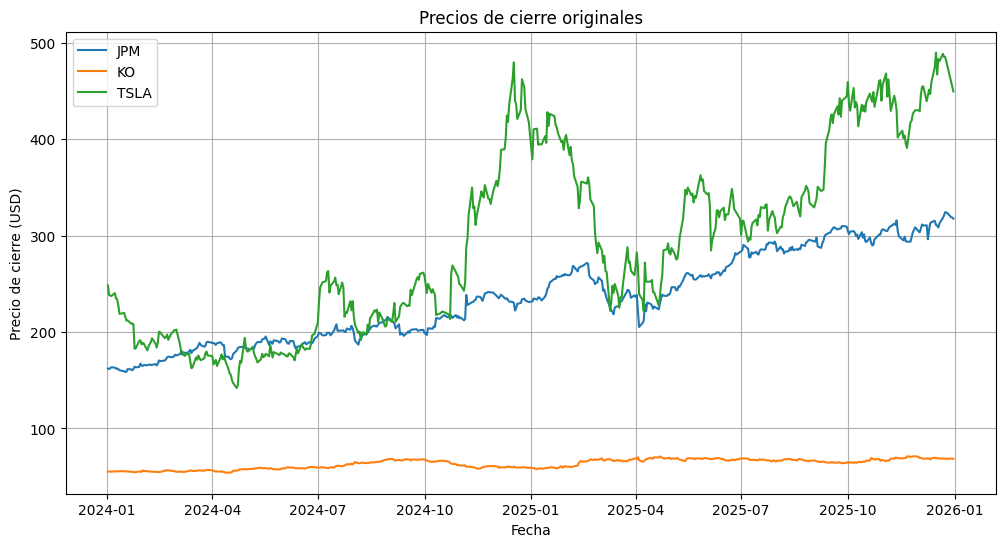

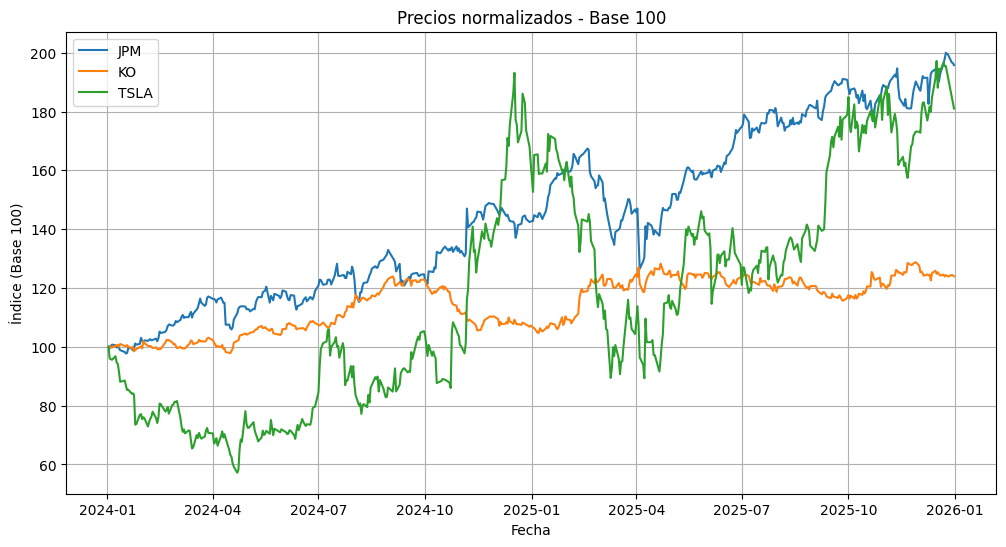

In [19]:
# 1. Extraer los precios de cierre
import pandas as pd

# Extraer los precios de cierre
cierres = pd.DataFrame({
    'JPM': datos['Close']['JPM'],
    'KO': datos['Close']['KO'],
    'TSLA': datos['Close']['TSLA']
})

print(cierres.head())

import matplotlib.pyplot as plt

# Extraer precios de cierre
cierres = datos['Close']

# Graficar precios originales
plt.figure(figsize=(12, 6))

plt.plot(cierres.index, cierres['JPM'], label='JPM')
plt.plot(cierres.index, cierres['KO'], label='KO')
plt.plot(cierres.index, cierres['TSLA'], label='TSLA')

plt.title('Precios de cierre originales')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (USD)')
plt.legend()
plt.grid(True)
plt.show()

 # Normalizar los precios tomando el primer día como base 100
precios_base100 = cierres / cierres.iloc[0] * 100

# Graficar precios normalizados
plt.figure(figsize=(12, 6))

plt.plot(precios_base100.index, precios_base100['JPM'], label='JPM')
plt.plot(precios_base100.index, precios_base100['KO'], label='KO')
plt.plot(precios_base100.index, precios_base100['TSLA'], label='TSLA')

plt.title('Precios normalizados - Base 100')
plt.xlabel('Fecha')
plt.ylabel('Índice (Base 100)')
plt.legend()
plt.grid(True)
plt.show()





Metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos por que si se busca  comparar el rendimiento histórico de varios activos, el gráfico normalizado en base 100 es más apropiado que el gráfico de precios originales.

La razón es que los precios absolutos no son directamente comparables.

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

/tmp/ipykernel_587/974581505.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  3 of 3 completed


Rendimientos diarios:
Ticker           JPM        KO      TSLA
Date                                    
2024-01-03 -0.004358  0.002340 -0.040134
2024-01-04  0.006636 -0.003336 -0.002181
2024-01-05  0.005017 -0.001506 -0.001849
2024-01-08 -0.001451  0.007374  0.012464
2024-01-09 -0.007906 -0.001830 -0.022832

Volatilidad de cada activo:
Ticker
JPM     0.014815
KO      0.008021
TSLA    0.040078
dtype: float64

El activo más volátil es: TSLA


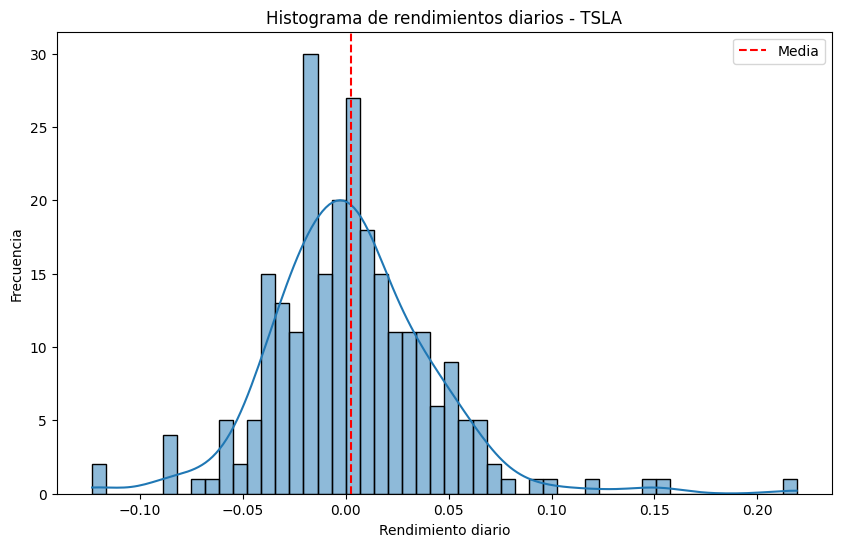

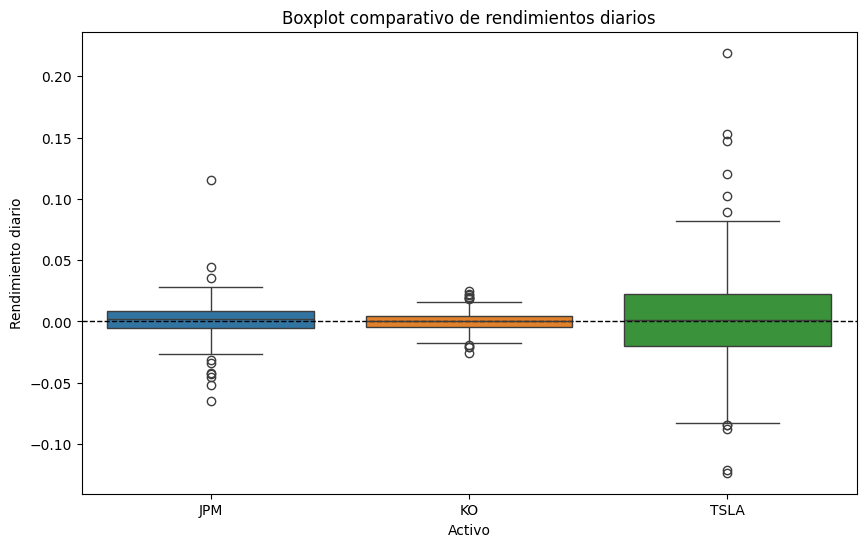

In [16]:
# 1. Calcular rendimientos import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Descargar datos
tickers = ["JPM", "KO", "TSLA"]
data = yf.download(tickers, start="2024-01-01", end="2025-01-01")

# Precios de cierre
close = data["Close"]

# Rendimientos diarios y eliminación de NaN
returns = close.pct_change().dropna()

# Mostrar rendimientos
print("Rendimientos diarios:")
print(returns.head())

# Volatilidad (desviación estándar)
volatility = returns.std()
print("\nVolatilidad de cada activo:")
print(volatility)

# Activo más volátil
most_volatile = volatility.idxmax()
print(f"\nEl activo más volátil es: {most_volatile}")


# 2. Histograma con el activo más volátil

plt.figure(figsize=(10, 6))
sns.histplot(returns[most_volatile], bins=50, kde=True)

plt.title(f"Histograma de rendimientos diarios - {most_volatile}")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")
plt.axvline(returns[most_volatile].mean(),
            color="red", linestyle="--", label="Media")

plt.legend()
plt.show()


# 3. Boxplot comparativo de rendimientos

plt.figure(figsize=(10, 6))
sns.boxplot(data=returns)

plt.title("Boxplot comparativo de rendimientos diarios")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.show()






Una mayor dispersion de los rendimientos implica mayor volatilidad por tanto mas incertidumbre por lo que se puede generar un solo dia, interpreta como mayor riesgo de mercado o riesgo de precio,

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Matriz de correlación:
Ticker       JPM        KO      TSLA
Ticker                              
JPM     1.000000  0.038966  0.233339
KO      0.038966  1.000000 -0.125055
TSLA    0.233339 -0.125055  1.000000


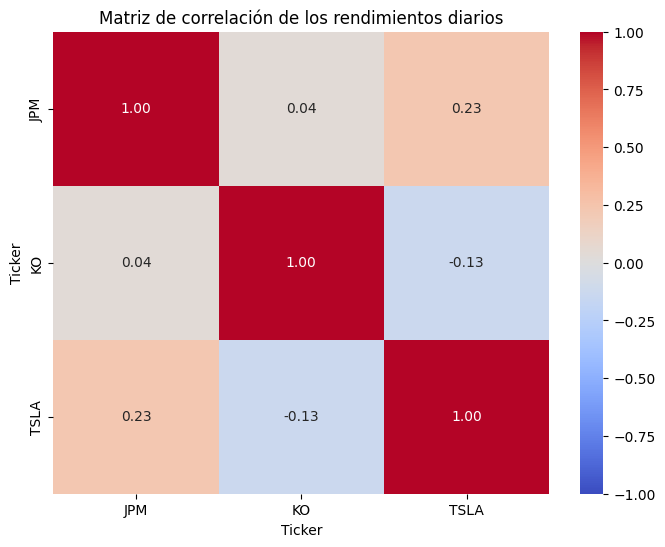

In [21]:
# 1. Calcular matriz de correlación

correlation_matrix = returns.corr(method="pearson")

print("Matriz de correlación:")
print(correlation_matrix)


# 2. Dibujar el Heatmap utilizando Seaborn

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,          # Mostrar los valores
    cmap="coolwarm",     # Colores para correlaciones positivas/negativas
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlación de los rendimientos diarios")
plt.show()


No existe una correlación fuerte entre ninguno de los tres activos, ya que ninguna correlación está cerca de +1 o -1.

La mayor correlación positiva es entre JPM y TSLA 0.23, pero sigue siendo relativamente baja. La correlación más negativa es entre KO y TSLA -0.13

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [18]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)

resumen = pd.DataFrame({
    "Media": returns.mean(),
    "Mediana": returns.median(),
    "Desviación Estándar": returns.std(),
    "Mínimo": returns.min(),
    "Máximo": returns.max()
})

# Mostrar el resumen
print("Resumen de estadísticas descriptivas:")
print(resumen)

# Resumen en porcentaje
resumen_pct = pd.DataFrame({
    "Media (%)": returns.mean() * 100,
    "Mediana (%)": returns.median() * 100,
    "Desviación Estándar (%)": returns.std() * 100,
    "Mínimo (%)": returns.min() * 100,
    "Máximo (%)": returns.max() * 100
})

resumen_pct = resumen_pct.round(4)

print("Resumen estadístico de los rendimientos diarios:")
print(resumen_pct)


Resumen de estadísticas descriptivas:
           Media   Mediana  Desviación Estándar    Mínimo    Máximo
Ticker                                                             
JPM     0.001524  0.001710             0.014815 -0.064678  0.115445
KO      0.000311  0.000720             0.008021 -0.025547  0.025046
TSLA    0.002721  0.001316             0.040078 -0.123346  0.219190
Resumen estadístico de los rendimientos diarios:
        Media (%)  Mediana (%)  Desviación Estándar (%)  Mínimo (%)  \
Ticker                                                                
JPM        0.1524       0.1710                   1.4815     -6.4678   
KO         0.0311       0.0720                   0.8021     -2.5547   
TSLA       0.2721       0.1316                   4.0078    -12.3346   

        Máximo (%)  
Ticker              
JPM        11.5445  
KO          2.5046  
TSLA       21.9190  


Para un inversionista ficticio, los resultados muestran perfiles de riesgo y rentabilidad claramente diferentes. TSLA presenta el mayor rendimiento diario promedio 0,2721%, pero también la mayor desviación estándar 4,0078%, lo que refleja una alta volatilidad y, por tanto, mayor riesgo. JPM ofrece un rendimiento promedio de 0,1524% con una volatilidad intermedia de 1,4815%, representando una alternativa de riesgo y rendimiento moderados. Por su parte, KO registra el menor rendimiento promedio 0,0311%, pero también la menor volatilidad 0,8021%, por lo que podría considerarse la opción más conservadora y estable de las tres.

En consecuencia, si el inversionista prioriza crecimiento y está dispuesto a asumir mayor riesgo, TSLA resulta más atractiva; si busca un equilibrio entre rentabilidad y riesgo, JPM puede ser una opción intermedia; y si su prioridad es preservar estabilidad y reducir la exposición a fluctuaciones, KO sería la alternativa más prudente. Los valores mínimos y máximos también confirman que TSLA ha experimentado las variaciones diarias más extremas.



